<a href="https://colab.research.google.com/github/Zaki2409/AI-Engineer-Hands-on/blob/master/Pytorch_NN_Training_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install numpy pandas torch scikit-learn

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import torch.nn as nn

In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df.shape

(569, 33)

In [6]:
df.drop(columns=['id','Unnamed: 32'], inplace=True)

In [7]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
#df.iloc[0]
#df.iloc[:] = df.head()
# all expect the target for x train and x test df.iloc[:,1:]
# only the target for y test and y train df.iloc[:,0]

In [9]:
df_test, df_train = train_test_split(df, test_size=0.2)

In [10]:
df_test.shape

(455, 31)

In [11]:
df_train.shape

(114, 31)

In [12]:
X_train = df_train.iloc[:,1:]
Y_train = df_train.iloc[:,0]

In [13]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
222,10.180,17.53,65.12,313.1,0.10610,0.08502,0.017680,0.019150,0.1910,0.06908,...,11.17,22.84,71.94,375.6,0.14060,0.14400,0.065720,0.05575,0.3055,0.08797
14,13.730,22.61,93.60,578.3,0.11310,0.22930,0.212800,0.080250,0.2069,0.07682,...,15.03,32.01,108.80,697.7,0.16510,0.77250,0.694300,0.22080,0.3596,0.14310
315,12.490,16.85,79.19,481.6,0.08511,0.03834,0.004473,0.006423,0.1215,0.05673,...,13.34,19.71,84.48,544.2,0.11040,0.04953,0.019380,0.02784,0.1917,0.06174
406,16.140,14.86,104.30,800.0,0.09495,0.08501,0.055000,0.045280,0.1735,0.05875,...,17.71,19.58,115.90,947.9,0.12060,0.17220,0.231000,0.11290,0.2778,0.07012
242,11.300,18.19,73.93,389.4,0.09592,0.13250,0.154800,0.028540,0.2054,0.07669,...,12.58,27.96,87.16,472.9,0.13470,0.48480,0.743600,0.12180,0.3308,0.12970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,12.030,17.93,76.09,446.0,0.07683,0.03892,0.001546,0.005592,0.1382,0.06070,...,13.07,22.25,82.74,523.4,0.10130,0.07390,0.007732,0.02796,0.2171,0.07037
39,13.480,20.82,88.40,559.2,0.10160,0.12550,0.106300,0.054390,0.1720,0.06419,...,15.53,26.02,107.30,740.4,0.16100,0.42250,0.503000,0.22580,0.2807,0.10710
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.059880,0.021800,0.2341,0.06963,...,10.01,19.23,65.59,310.1,0.09836,0.16780,0.139700,0.05087,0.3282,0.08490
552,12.770,29.43,81.35,507.9,0.08276,0.04234,0.019970,0.014990,0.1539,0.05637,...,13.87,36.00,88.10,594.7,0.12340,0.10640,0.086530,0.06498,0.2407,0.06484


In [14]:
Y_train

,diagnosis
222,B
14,M
315,B
406,B
242,B
...,...
327,B
39,M
63,B
552,B


In [15]:
X_test = df_test.iloc[:,1:]
Y_test = df_test.iloc[:,0]

In [16]:
X_test

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
536,14.27,22.55,93.77,629.8,0.10380,0.11540,0.14630,0.06139,0.1926,0.05982,...,15.29,34.27,104.30,728.3,0.1380,0.2733,0.4234,0.13620,0.2698,0.08351
323,20.34,21.51,135.90,1264.0,0.11700,0.18750,0.25650,0.15040,0.2569,0.06670,...,25.30,31.86,171.10,1938.0,0.1592,0.4492,0.5344,0.26850,0.5558,0.10240
312,12.76,13.37,82.29,504.1,0.08794,0.07948,0.04052,0.02548,0.1601,0.06140,...,14.19,16.40,92.04,618.8,0.1194,0.2208,0.1769,0.08411,0.2564,0.08253
266,10.60,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.02642,0.1922,0.06491,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.1916,0.07926,0.2940,0.07587
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,19.80,21.56,129.70,1230.0,0.09383,0.13060,0.12720,0.08691,0.2094,0.05581,...,25.73,28.64,170.30,2009.0,0.1353,0.3235,0.3617,0.18200,0.3070,0.08255
53,18.22,18.70,120.30,1033.0,0.11480,0.14850,0.17720,0.10600,0.2092,0.06310,...,20.60,24.13,135.10,1321.0,0.1280,0.2297,0.2623,0.13250,0.3021,0.07987
91,15.37,22.76,100.20,728.2,0.09200,0.10360,0.11220,0.07483,0.1717,0.06097,...,16.43,25.84,107.50,830.9,0.1257,0.1997,0.2846,0.14760,0.2556,0.06828
410,11.36,17.57,72.49,399.8,0.08858,0.05313,0.02783,0.02100,0.1601,0.05913,...,13.05,36.32,85.07,521.3,0.1453,0.1622,0.1811,0.08698,0.2973,0.07745


In [17]:
Y_test

,diagnosis
536,M
323,M
312,B
266,B
8,M
...,...
218,M
53,M
91,M
410,B


In [18]:
scale= StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.fit_transform(X_test)

In [19]:
X_train

array([[-1.1172409 , -0.4724742 , -1.10967765, ..., -0.91100199,
         0.4599982 ,  0.12786527],
       [-0.14342753,  0.81019624,  0.0346391 , ...,  1.55949422,
         1.51190508,  2.89941286],
       [-0.48357643, -0.64417024, -0.54434982, ..., -1.32876358,
        -1.75270058, -1.19079413],
       ...,
       [-1.39347473, -1.39912784, -1.34754124, ..., -0.98404666,
         0.90137133, -0.02647268],
       [-0.40676861,  2.53220654, -0.45756175, ..., -0.7728458 ,
        -0.79995682, -1.034948  ],
       [-0.05564717,  1.95651981, -0.05455975, ..., -0.17681333,
        -1.1052237 , -0.11143396]])

In [20]:
X_test

array([[ 4.99288237e-02,  7.51247596e-01,  8.26591529e-02, ...,
         3.37981723e-01, -3.49114970e-01, -3.69666135e-03],
       [ 1.79000632e+00,  5.13648937e-01,  1.82946013e+00, ...,
         2.36160647e+00,  4.12061457e+00,  1.07370651e+00],
       [-3.82940538e-01, -1.34601750e+00, -3.93326493e-01, ...,
        -4.58772722e-01, -5.58535865e-01, -5.95915849e-02],
       ...,
       [ 3.65264120e-01,  7.99224249e-01,  3.49260869e-01, ...,
         5.12353016e-01, -5.71038605e-01, -8.72349403e-01],
       [-7.84276370e-01, -3.86484447e-01, -7.99655702e-01, ...,
        -4.14873984e-01,  8.06667166e-02, -3.49332617e-01],
       [-2.65406473e-01,  5.82187012e-01, -2.63549919e-01, ...,
         7.12727047e-01,  1.20591331e+00,  7.18944851e-01]])

In [21]:
encoder = LabelEncoder()
Y_train = encoder.fit_transform(Y_train)
Y_test = encoder.fit_transform(Y_test)

In [22]:
Y_train

array([0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0])

In [23]:
Y_test

array([1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,

CONVERT NUMPY TO TENSOR TO USE GPU

In [24]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_tensor  = torch.tensor(Y_test, dtype=torch.float32).to(device)

In [25]:
X_train_tensor.shape

torch.Size([114, 30])

In [26]:
X_test_tensor.shape

torch.Size([455, 30])

In [27]:
Y_test_tensor.shape

torch.Size([455])

In [28]:
Y_train_tensor.shape

torch.Size([114])

DATA SET AND DATA LOADER

In [29]:
from torch.utils.data import Dataset, DataLoader

In [30]:
class Customdataset(Dataset):
  def __init__(self, X, y): # X IS FEAURES AND y is label
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


In [31]:
train_dataset = Customdataset(X_train_tensor, Y_train_tensor)
test_dataset = Customdataset(X_test_tensor, Y_test_tensor)

In [32]:
train_dataset[10]

(tensor([-0.2422, -0.7603, -0.2667, -0.3141, -1.6945, -0.5881, -0.1280, -0.5517,
         -1.5044, -0.5926, -1.0090, -0.1661, -0.9669, -0.7030, -0.3651,  0.3919,
          0.7473, -0.3123, -1.1286, -0.0194, -0.4243, -0.5922, -0.4616, -0.4486,
         -1.2288,  0.0315,  0.2723, -0.4016, -1.4980, -0.4598], device='cuda:0'),
 tensor(0., device='cuda:0'))

In [33]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

#DEFINING A MODEL

In [51]:
class MyNN2(nn.Module):

  def __init__(self,num_features):
    super().__init__()
    self.linear = nn.Linear(num_features,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,features):
    out = self.linear(features)
    out = self.sigmoid(out)
    return out


In [52]:
loss_function = nn.BCELoss()

IMPORTATN PAPRAMS

In [53]:
learning_rate = 0.1
epochs = 25

TRAINING PARAMETER

In [56]:
# create model
model2 = MyNN2(X_train_tensor.shape[1]).to(device)

#optimizer
optimizer = torch.optim.SGD(model2.parameters(), lr=learning_rate)

#loss function
loss_function = nn.BCELoss()

In [57]:
# define loop
for epoch in range(epochs):
  for batch_feaures, batch_labels in train_loader:
    # forward pass
    y_pred = model2.forward(batch_feaures)

    # loss calculate
    loss = loss_function(y_pred, batch_labels.view(-1,1))

    # zero gradients
    optimizer.zero_grad()

    # backward pass
    loss.backward()

    # parameters update
    optimizer.step()


  print(f'Epoch: {epoch+1}, Loss:{loss.item()}')

Epoch: 1, Loss:0.4421054422855377
Epoch: 2, Loss:0.26926475763320923
Epoch: 3, Loss:0.2979307472705841
Epoch: 4, Loss:0.17466554045677185
Epoch: 5, Loss:0.23570747673511505
Epoch: 6, Loss:0.17634661495685577
Epoch: 7, Loss:0.17374254763126373
Epoch: 8, Loss:0.0850931778550148
Epoch: 9, Loss:0.09304916113615036
Epoch: 10, Loss:0.11906427890062332
Epoch: 11, Loss:0.14507479965686798
Epoch: 12, Loss:0.10008635371923447
Epoch: 13, Loss:0.04957260563969612
Epoch: 14, Loss:0.12931472063064575
Epoch: 15, Loss:0.06419264525175095
Epoch: 16, Loss:0.1072172075510025
Epoch: 17, Loss:0.07113432884216309
Epoch: 18, Loss:0.21252603828907013
Epoch: 19, Loss:0.25063833594322205
Epoch: 20, Loss:0.023123769089579582
Epoch: 21, Loss:0.1926845759153366
Epoch: 22, Loss:0.07848658412694931
Epoch: 23, Loss:0.05018298700451851
Epoch: 24, Loss:0.2167782485485077
Epoch: 25, Loss:0.23567499220371246


In [60]:
# model 2 evaluation with test loader

model2.eval() # set moodel to evaluation mode
accuracy_list =[]

with torch.no_grad():
  for batch_feaures, batch_labels in test_loader:
    y_pred = model2.forward(batch_feaures) # forward pass
    y_pred = (y_pred > 0.8).float() #convert probabalitlies to biary classification


    batch_accuracy = (y_pred.view(-1) == batch_labels).float().mean().item() #calcualte accuracy for the current batch
    accuracy_list.append(batch_accuracy)

#calcualte overall accuracy
  overall_accuracy = sum(accuracy_list) / len(accuracy_list)
  print(f'Accuracy: {overall_accuracy:4f}')

Accuracy: 0.934226


In [61]:
model2.linear.bias

Parameter containing:
tensor([-0.1600], device='cuda:0', requires_grad=True)

In [62]:
model2.linear.weight

Parameter containing:
tensor([[ 0.3291,  0.2147,  0.3348,  0.3498,  0.1333,  0.0501,  0.4141,  0.5076,
          0.3286, -0.0486,  0.5662,  0.0461,  0.1768,  0.4090, -0.0677, -0.2349,
          0.0296,  0.1061, -0.2778, -0.1893,  0.4758,  0.3012,  0.2138,  0.3738,
          0.1082,  0.1716,  0.3322,  0.5639,  0.1664, -0.0846]],
       device='cuda:0', requires_grad=True)

In [64]:
!pip install torchinfo

In [66]:
from torchinfo import summary
summary(model2, input_size=(455, 30))

Layer (type:depth-idx)                   Output Shape              Param #
MyNN2                                    [455, 1]                  --
├─Linear: 1-1                            [455, 1]                  31
├─Sigmoid: 1-2                           [455, 1]                  --
Total params: 31
Trainable params: 31
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.05
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.06

In [69]:
#Prepare background data
#SHAP’s DeepExplainer needs a representative sample from the training set to learn the “base” distribution.
#Use a small subset (e.g., 100–200 rows) of your training data (already converted to tensor).


background = X_train_tensor[torch.randperm(len(X_train_tensor))[:100]]

In [70]:
#Create the SHAP explainer Use shap.DeepExplainer (designed for neural networks). It requires the model and the background dataset.
import shap
explainer = shap.DeepExplainer(model2, background)

In [73]:
#Compute SHAP values for the test set
#You have X_test_tensor_for_nnmodule (test features).
#You can compute SHAP values for all test instances or just a few.

shap_values = explainer.shap_values(X_test_tensor)

In [84]:
# shap_values is shape (455, 30, 1) – squeeze the last dimension
shap_vals = shap_values.squeeze(-1)   # now (455, 30)

In [85]:
#SHAP's plotting functions (summary_plot, waterfall_plot, etc.) require CPU‑based numpy arrays or pandas DataFrames. They cannot directly handle GPU tensors.
X_test_np = X_test_tensor.cpu().numpy()

In [86]:
#X_train.columns doesn't exist because X_train is now a NumPy array. Use the original column names from df:
feature_names = df.columns[1:].tolist()   # skip 'diagnosis'

In [87]:
print("type(shap_values):", type(shap_values))
if isinstance(shap_values, list):
    print("len(shap_values):", len(shap_values))
    for i, arr in enumerate(shap_values):
        print(f"shap_values[{i}].shape:", arr.shape)
else:
    print("shap_values.shape:", shap_values.shape)

type(shap_values): <class 'numpy.ndarray'>
shap_values.shape: (455, 30, 1)


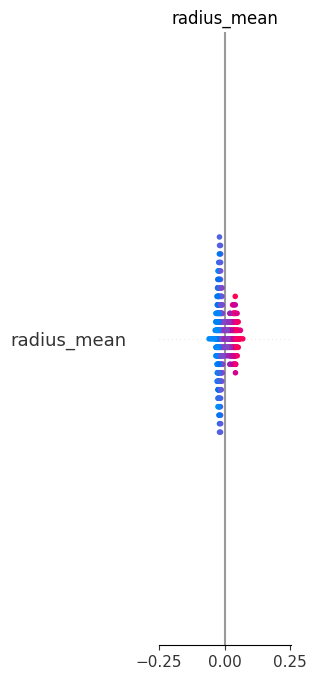

In [88]:
#Visualize the results
#You can now use SHAP’s plotting functions:

#Summary plot – global feature importance:
shap.summary_plot(shap_values, X_test_np, feature_names=feature_names)


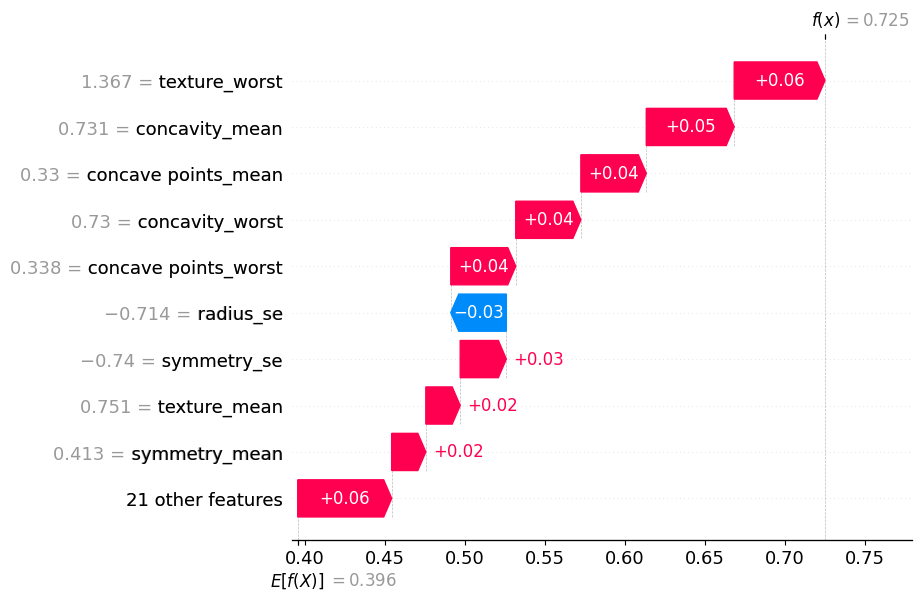

In [90]:
#Waterfall plot – local explanation for a single prediction:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals[0],
        base_values=explainer.expected_value,  # scalar for single output
        data=X_test_np[0],
        feature_names=feature_names
    )
)